In [1]:
from romda.observations import Observations
from romda.models.physical import VdP


obs = Observations(model=VdP, 
                    t_start=2.0, 
                    t_stop=2.5, 
                    Nt_obs=50, 
                    add_noise=True,
                    Nq=2,
                    noise_type='gauss, add',
                    noise_level=0.1,
                    manual_bias='linear'
                    )


...Applying manual bias: linear
...Adding noise: gauss, add with level 0.1.


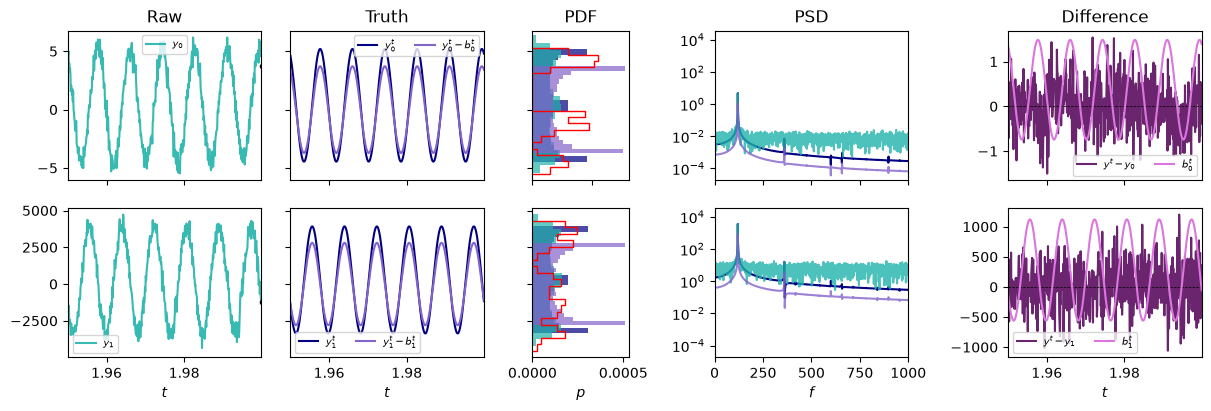

In [2]:

Observations.plot_truth(obs, f_max=1000, window=.05)

We want to model the truth $y^{true}$ using a reduced order model, which may be biased. In this twin experiment case, the ROM is  show in the figure above as $y^{true}-b^{true}$.


To infer the bias $b^{true}$ from the obsdervation data $d$ (red dots) without knowing the truth $y^{true}$, we need to make some assumtions. First, we will assume that we have a model of the system which gives some estimate of the system as 
$$
y^{rom}(t) = y^{true}(t) + b^{true}(t) + \varepsilon_y
$$
and the observations 
$$
d(t^{obs}) = y^{true}(t^{obs}) + \varepsilon_{obs}, 
$$
where $\varepsilon$ is noise. 

`ESN_bias` — the workhorse used below — learns the bias dynamics with an echo state network. `romda.bias_estimators` also provides the simple limits `ConstantBias` and `NoBias`, useful as baselines and for filters that do not need a learned bias model.


In [3]:
from romda.bias_estimators import ESN_bias
from romda.utils import set_working_directories 
from pathlib import Path

# First, initialize a ROM 
rom = VdP(Nq=2
    )


results_dir = set_working_directories('VdP')[1]

training_data_filename = Path(results_dir) / 'Tutorial_05_bias_training_data2_b'


# Then, initialize a Bias object using the ROM and the Observations
# Note: std_alpha is intentionally omitted -- this ROM has no est_alpha
# (no parameters being estimated), so std_alpha must be left as its
# default (None -> becomes an empty dict) rather than a scalar.
bias = ESN_bias(rom=rom,
                reference_data=obs,
                t_min=0.5,
                t_max=2.0,
                training_data_filename=training_data_filename,
                # Parameters for training data generation (if no file found or loading fails)
                std_phi=0.1,
                biased_observations=False,
                # Other parameters for the bias model can be added here as needed
                N_units=50,
                auto_save=True,
                N_func_evals=20,
                N_grid=4,
                t_train=0.2, 
                t_val=0.02,
                upsample=4,
                N_ens=20
                )


✓ Found matching config: dfb948d8e26f1930
Configuration loaded from ...config/esn_configs/dfb948d8e26f1930/esn_config.yaml


In [4]:
bias.print_bias_parameters()


ESN_bias
  L = 1
  augment_data_length = 2
  bayesian_update = False
  biased_observations = False
  upsample = 4
  ====Forecaster model ====
    Model class: ESN_model
    N_units = 50
    N_wash = 5
    rho = 0.2
    sigma_in = 1.3282792020708338
    update_reservoir = True
    update_state = True
    upsample = 4


In [5]:
# test forecasting the bias
state, t = bias.time_integrate(Nt=1000)
bias.update_history(state, t)


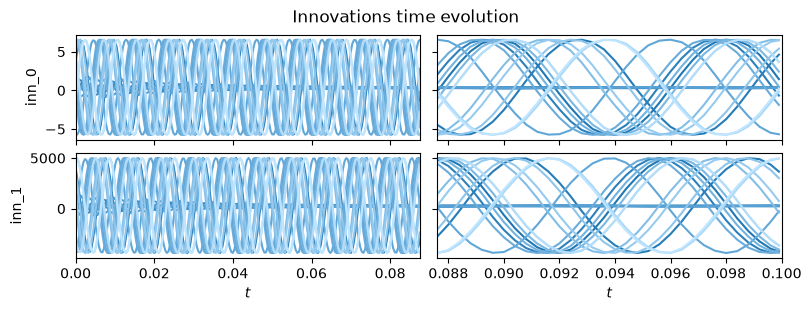

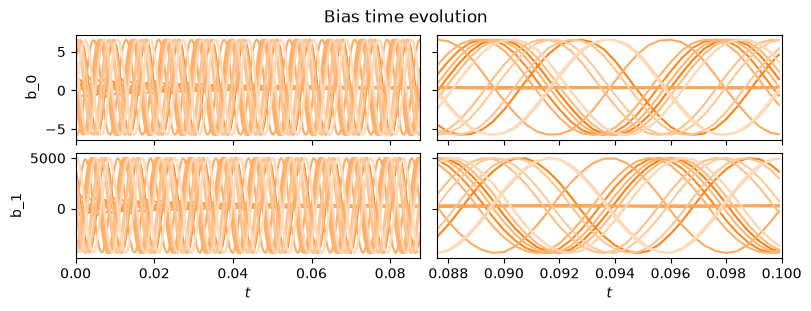

In [6]:
bias.visualize_bias_and_innovations()

## The ESN Jacobian $J = \mathrm{d}\mathbf{b}/\mathrm{d}(\mathbf{M}\boldsymbol{\psi})$

The r-EnKF filter needs the sensitivity of the bias estimate to the observable input, $J$, to correctly
propagate the effect of the bias correction through the Kalman gain (see `rBA_EnKF` in `data_assimilation.py`).
This Jacobian is computed analytically in closed form by the ESN (`EchoStateNetwork.Jacobian`, exposed via
`bias.state_derivative()`), since the ESN is a differentiable map (input -> reservoir -> linear readout).

Below we:
1. Compute the analytical Jacobian at the ESN's current state.
2. Estimate the same Jacobian numerically via central finite differences on the ESN's own one-step map
   (`esn.step`), perturbing each input dimension independently.
3. Compare the two -- they should agree to a few significant figures, limited only by the finite-difference
   step size and floating-point precision.


In [7]:
import numpy as np

esn = bias.forecaster  # the trained EchoStateNetwork / ESN_model

# Use the ensemble-mean physical state and reservoir state as the point at which
# to evaluate the Jacobian (same convention as bias.state_derivative()).
current_state = bias.current_state                                    # shape (N_dim + N_units, N_ens)
u_in = np.mean(current_state[:bias.N_dim], axis=-1, keepdims=True)     # (N_dim, 1)
r_in = np.mean(current_state[-bias.N_hidden:], axis=-1, keepdims=True) # (N_units, 1)

print('Input (u) dimension:', u_in.shape[0])
print('Reservoir dimension:', r_in.shape[0])


Input (u) dimension: 2
Reservoir dimension: 50


In [8]:
# Analytical Jacobian: d(u_out)/d(u_in), evaluated via the ESN's closed-loop linearization
J_analytic = esn.Jacobian(open_loop_J=True, u_in=u_in, r_in=r_in)

print('Analytical Jacobian J = d(u_out)/d(u_in):')
print(J_analytic)


Analytical Jacobian J = d(u_out)/d(u_in):
[[ 1.88444846e-01  2.28549574e-05]
 [-1.89135075e+01  1.61506693e-01]]


In [9]:
# Numerical check via central finite differences on the ESN's own one-step map.
# For each input dimension i, perturb u_in[i] by +-eps and re-evaluate esn.step(...);
# the resulting output difference approximates column i of the Jacobian.
eps = 1e-6
N_in = u_in.shape[0]

J_numeric = np.zeros_like(J_analytic)
for i in range(N_in):
    u_plus, u_minus = u_in.copy(), u_in.copy()
    u_plus[i] += eps
    u_minus[i] -= eps

    out_plus, _ = esn.step(u_plus, r_in)
    out_minus, _ = esn.step(u_minus, r_in)

    J_numeric[:, i] = ((out_plus - out_minus) / (2 * eps)).flatten()

print('Finite-difference Jacobian:')
print(J_numeric)


Finite-difference Jacobian:
[[ 1.88444837e-01  2.28510544e-05]
 [-1.89135017e+01  1.61506250e-01]]


In [10]:
abs_err = np.abs(J_analytic - J_numeric)
rel_err = abs_err / (np.max(np.abs(J_analytic)) + 1e-12)

print(f'Max absolute error: {abs_err.max():.3e}')
print(f'Max relative error: {rel_err.max():.3e}')

assert rel_err.max() < 1e-3, 'Analytical and numerical Jacobians disagree beyond finite-difference tolerance!'
print('\nOK: analytical Jacobian matches the finite-difference approximation.')


Max absolute error: 5.860e-06
Max relative error: 3.098e-07

OK: analytical Jacobian matches the finite-difference approximation.


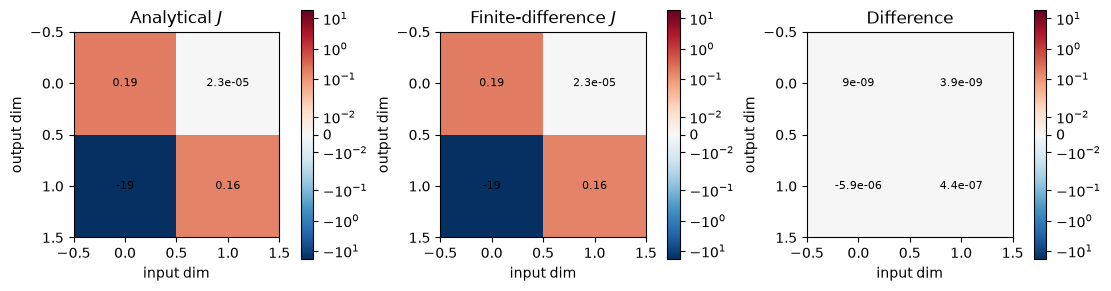

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

fig, axs = plt.subplots(1, 3, figsize=(11, 3.2), layout='constrained')
vmax = np.max(np.abs(J_analytic))
norm = SymLogNorm(linthresh=max(vmax * 1e-3, 1e-8), vmin=-vmax, vmax=vmax)

for ax, mat, title in zip(axs, [J_analytic, J_numeric, J_analytic - J_numeric],
                          ['Analytical $J$', 'Finite-difference $J$', 'Difference']):
    im = ax.imshow(mat, cmap='RdBu_r', norm=norm)
    ax.set_title(title)
    ax.set_xlabel('input dim')
    ax.set_ylabel('output dim')
    for (r, cix), val in np.ndenumerate(mat):
        ax.text(cix, r, f'{val:.2g}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)


### Relating this to `bias.state_derivative()`

`bias.state_derivative()` is what the r-EnKF filter actually calls during the analysis step
(see `EnsembleEstimator.analysis_step` in `estimators/ensembles.py`). It wraps the raw ESN Jacobian above: it selects the
rows/columns corresponding to `bias.bias_idx` and returns the **negative transpose** of that sub-matrix
(matching the sign convention $\mathbf{y}=\mathbf{q}+\mathbf{b}$ used in the filter's cost function).


In [12]:
J_filter = bias.state_derivative()
print('J used inside the DA filter (bias.state_derivative()):')
print(J_filter)

# Reproduce it directly from the raw ESN Jacobian to confirm the relationship:
bias_idx = np.array(bias.bias_idx)
J_from_raw = -J_analytic[bias_idx, :][:, bias_idx].T
print('\nReconstructed from the raw ESN Jacobian (-J[bias_idx][:,bias_idx].T):')
print(J_from_raw)

assert np.allclose(J_filter, J_from_raw)
print('\nOK: matches bias.state_derivative() exactly.')


J used inside the DA filter (bias.state_derivative()):
[[-1.88444846e-01  1.89135075e+01]
 [-2.28549574e-05 -1.61506693e-01]]

Reconstructed from the raw ESN Jacobian (-J[bias_idx][:,bias_idx].T):
[[-1.88444846e-01  1.89135075e+01]
 [-2.28549574e-05 -1.61506693e-01]]

OK: matches bias.state_derivative() exactly.
